# CPDO — Constant Proportion Debt Obligation

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Section 1 — Data

In [2]:
# 1.1 Load CDX.NA.IG 5Y spread data
cdx = pd.read_csv(
    'CDX IG CDSI GEN 5Y Corp(CDX IG CDSI GEN 5Y Corp).csv',
    sep=';',
    header=0,
    names=['Date', 'Spread']
)
cdx['Date'] = pd.to_datetime(cdx['Date'])
cdx['Spread'] = cdx['Spread'].astype(str).str.replace(',', '.', regex=False).astype(float)
cdx = cdx.sort_values('Date').reset_index(drop=True).dropna()

print(f'CDX rows:   {len(cdx)}')
print(f'Date range: {cdx["Date"].min().date()}  to  {cdx["Date"].max().date()}')
cdx.head(3)

CDX rows:   3655
Date range: 2011-09-09  to  2026-04-23


,Date,Spread
0,2011-09-09,132.25
1,2011-09-12,135.75
2,2011-09-13,132.25


In [3]:
# 1.2 Load SOFR daily rate and convert from percent to decimal
sofr = pd.read_csv(
    'SOFR rates(Daily).csv',
    sep=';',
    header=0,
    names=['Date', 'Rate']
)
sofr['Date'] = pd.to_datetime(sofr['Date'])
sofr['Rate'] = sofr['Rate'].astype(str).str.replace(',', '.', regex=False).astype(float) / 100
sofr = sofr.sort_values('Date').reset_index(drop=True).dropna()

print(f'SOFR rows:  {len(sofr)}')
print(f'Date range: {sofr["Date"].min().date()}  to  {sofr["Date"].max().date()}')
sofr.head(3)

SOFR rows:  5579
Date range: 2004-01-02  to  2026-04-21


,Date,Rate
0,2004-01-02,0.0336
1,2004-01-05,0.0339
2,2004-01-06,0.0326


In [4]:
# 1.3 Validate both datasets
issues = []

if cdx['Date'].duplicated().any():
    issues.append('CDX has duplicate dates')
if sofr['Date'].duplicated().any():
    issues.append('SOFR has duplicate dates')
if cdx['Spread'].isna().any():
    issues.append('CDX has missing spreads')
if sofr['Rate'].isna().any():
    issues.append('SOFR has missing rates')
if (cdx['Spread'] <= 0).any():
    issues.append('CDX has non-positive spreads')
if cdx['Date'].diff().dt.days.dropna().max() > 5:
    issues.append('CDX has a gap larger than 5 calendar days')

if issues:
    for issue in issues:
        print('Issue:', issue)
else:
    print('Validation passed')
    print(f'CDX:  {len(cdx)} rows | {cdx["Date"].min().date()} to {cdx["Date"].max().date()} | spread {cdx["Spread"].min():.1f} to {cdx["Spread"].max():.1f} bps')
    print(f'SOFR: {len(sofr)} rows | {sofr["Date"].min().date()} to {sofr["Date"].max().date()} | rate {sofr["Rate"].min()*100:.2f}% to {sofr["Rate"].max()*100:.2f}%')

Validation passed
CDX:  3655 rows | 2011-09-09 to 2026-04-23 | spread 43.8 to 151.8 bps
SOFR: 5579 rows | 2004-01-02 to 2026-04-21 | rate 0.19% to 5.23%


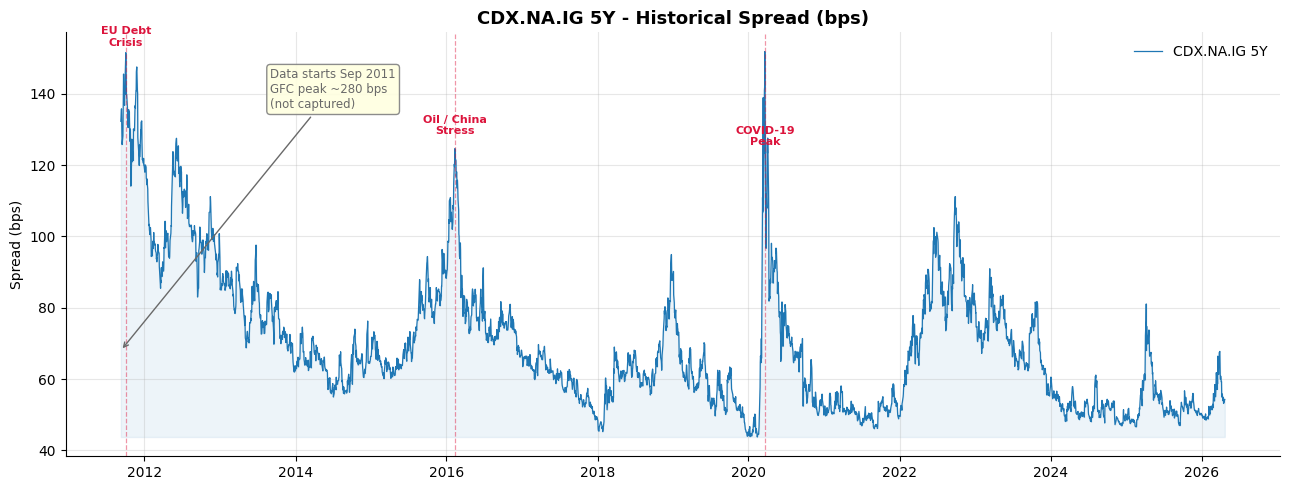

In [5]:
# 1.4 Plot CDX spread history with key events marked
fig, ax = plt.subplots()
ax.plot(cdx['Date'], cdx['Spread'], color='#1f77b4', linewidth=0.9, label='CDX.NA.IG 5Y')
ax.fill_between(cdx['Date'], cdx['Spread'].min(), cdx['Spread'], alpha=0.08, color='#1f77b4')

# Mark key credit stress events
events = [
    ('2011-10-04', 'EU Debt\nCrisis'),
    ('2016-02-11', 'Oil / China\nStress'),
    ('2020-03-23', 'COVID-19\nPeak'),
]
for date_str, label in events:
    d = pd.to_datetime(date_str)
    y = cdx.loc[(cdx['Date'] - d).abs().idxmin(), 'Spread']
    ax.axvline(d, color='crimson', linestyle='--', alpha=0.45, linewidth=0.9)
    ax.text(d, y + 4, label, fontsize=8, ha='center', color='crimson', fontweight='bold')

ax.annotate(
    'Data starts Sep 2011\nGFC peak ~280 bps\n(not captured)',
    xy=(pd.to_datetime('2011-09-09'), 68),
    xytext=(pd.to_datetime('2013-09-01'), 136),
    fontsize=8.5, color='dimgray',
    arrowprops=dict(arrowstyle='->', color='dimgray', lw=1.0),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.9),
)

ax.set_title('CDX.NA.IG 5Y - Historical Spread (bps)', fontsize=13, fontweight='bold')
ax.set_ylabel('Spread (bps)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('outputs/01_cdx_spread.png', dpi=150, bbox_inches='tight')
plt.show()

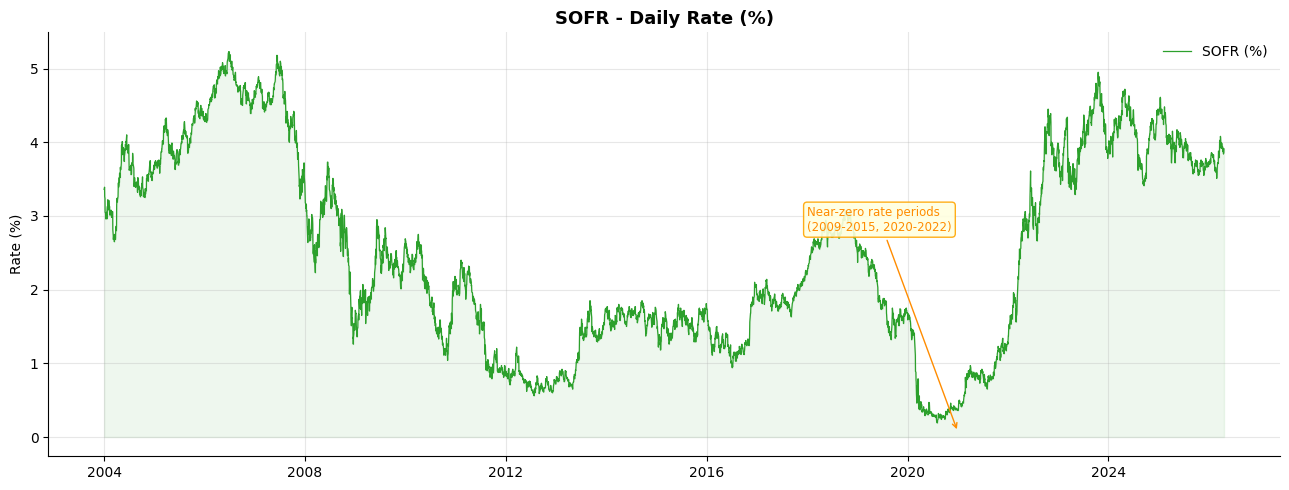

In [6]:
# 1.5 Plot SOFR rate history
fig, ax = plt.subplots()
ax.plot(sofr['Date'], sofr['Rate'] * 100, color='#2ca02c', linewidth=0.9, label='SOFR (%)')
ax.fill_between(sofr['Date'], 0, sofr['Rate'] * 100, alpha=0.08, color='#2ca02c')

ax.annotate(
    'Near-zero rate periods\n(2009-2015, 2020-2022)',
    xy=(pd.to_datetime('2021-01-01'), 0.07),
    xytext=(pd.to_datetime('2018-01-01'), 2.8),
    fontsize=8.5, color='darkorange',
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.0),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='orange', alpha=0.9),
)

ax.set_title('SOFR - Daily Rate (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('outputs/02_sofr_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# 1.6 Summary statistics (SOFR restricted to CDX date range)
pcts = [0.05, 0.25, 0.5, 0.75, 0.95]
sofr_in_range = sofr[sofr['Date'] >= cdx['Date'].min()]['Rate'] * 100

stats = pd.DataFrame({
    'CDX Spread (bps)':   cdx['Spread'].describe(percentiles=pcts),
    'SOFR % [2011-2026]': sofr_in_range.describe(percentiles=pcts),
}).round(3)

stats

,CDX Spread (bps),SOFR % [2011-2026]
count,3655.000,3653.000
mean,69.591,2.119
std,19.013,1.262
min,43.750,0.190
5%,48.875,0.410
25%,54.604,1.150
50%,65.059,1.710
75%,78.986,3.290
95%,108.125,4.310
max,151.798,4.950


**Data limitations:** CDX starts Sep 2011 — GFC (2007–2009) is absent. CDX.NA.IG peaked at ~280 bps during the crisis, nearly double the sample maximum. Addressed via stress testing in Section 9.

---
## Section 2 — CPDO Design

In [8]:
from dataclasses import dataclass

@dataclass
class CPDOParams:
    # Capital structure
    initial_nav:     float = 100.0
    target_nav:      float = 150.0   # cash-out trigger
    floor_nav:       float = 10.0    # default trigger (90% principal loss)

    # Portfolio
    max_leverage:    float = 15.0
    n_names:         int   = 125     # CDX.NA.IG index size
    risky_duration:  float = 4.5     # years
    recovery_rate:   float = 0.40

    # Costs and coupon
    investor_spread: float = 0.0150  # 150 bps over SOFR, paid quarterly
    management_fee:  float = 0.0030  # 30 bps per year
    roll_cost_bps:   float = 2.0     # bps of exposure per 6-month roll
    roll_every:      int   = 126     # steps between rolls (~6 months)

    # Simulation grid
    T:               float = 10.0
    dt:              float = 1 / 252

cpdo = CPDOParams()
dv01 = cpdo.risky_duration * 1e-4   # price sensitivity per bp per $1 notional
lgd  = 1.0 - cpdo.recovery_rate     # loss given default

# Shared time axis for all path plots (defined once here, reused everywhere)
n_steps   = int(cpdo.T / cpdo.dt)
time_axis = np.linspace(0, cpdo.T, n_steps + 1)

print(f'DV01:        {dv01:.5f}  per bp per $1 notional')
print(f'LGD:         {lgd:.0%}')
print(f'Total steps: {n_steps} ({int(cpdo.T)} years at dt = 1/252)')

DV01:        0.00045  per bp per $1 notional
LGD:         60%
Total steps: 2520 (10 years at dt = 1/252)


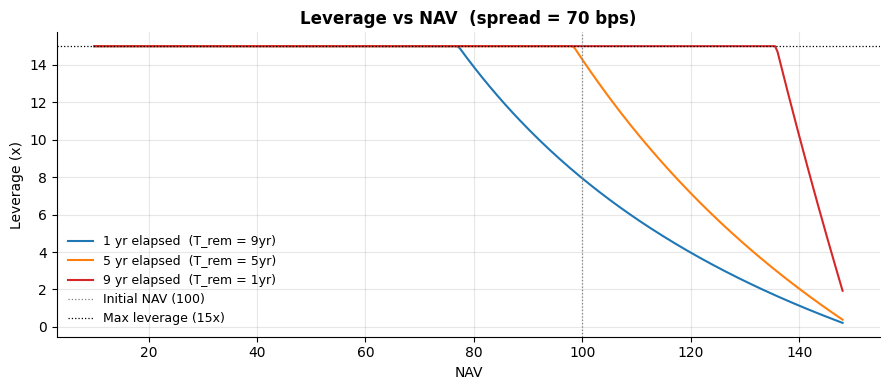

In [9]:
# Leverage = shortfall / (nav * carry_rate * time_remaining)
# Capped at max_leverage, floored at 0
def compute_leverage(nav, spread, step, cpdo):
    time_remaining = max(cpdo.T - step * cpdo.dt, cpdo.dt)
    shortfall      = np.maximum(cpdo.target_nav - nav, 0.0)
    carry_rate     = np.maximum(spread / 10_000, 1e-9)
    nav_safe       = np.maximum(nav, 1e-9)
    leverage       = shortfall / (nav_safe * carry_rate * time_remaining)
    return np.clip(leverage, 0.0, cpdo.max_leverage)

# Show how leverage changes with NAV at three points in the product's life
nav_range   = np.linspace(10, 148, 300)
demo_spread = 70  # bps

leverage_curves = [
    (int(cpdo.T * 0.10 * 252), '1 yr elapsed  (T_rem = 9yr)', '#1f77b4'),
    (int(cpdo.T * 0.50 * 252), '5 yr elapsed  (T_rem = 5yr)', '#ff7f0e'),
    (int(cpdo.T * 0.90 * 252), '9 yr elapsed  (T_rem = 1yr)', '#d62728'),
]

fig, ax = plt.subplots(figsize=(9, 4))
for step, label, color in leverage_curves:
    ax.plot(nav_range, compute_leverage(nav_range, demo_spread, step, cpdo),
            color=color, linewidth=1.5, label=label)

ax.axvline(cpdo.initial_nav, color='gray', linestyle=':', linewidth=0.9, label='Initial NAV (100)')
ax.axhline(cpdo.max_leverage, color='black', linestyle=':', linewidth=0.9,
           label=f'Max leverage ({cpdo.max_leverage:.0f}x)')
ax.set_xlabel('NAV')
ax.set_ylabel('Leverage (x)')
ax.set_title(f'Leverage vs NAV  (spread = {demo_spread} bps)', fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/03_leverage_vs_nav.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Cash flow breakdown at representative values: NAV=100, spread=70bps, SOFR=4%, year 1
nav_demo    = 100.0
spread_demo = 70.0
sofr_demo   = 0.04
lev_demo    = compute_leverage(nav_demo, spread_demo, 252, cpdo)
exp_demo    = lev_demo * nav_demo

print(f'Leverage = {lev_demo:.2f}x   |   Exposure = {exp_demo:.1f}')
print()
print(f'{"Component":<37}  {"Daily":>8}  {"Annual est.":>11}')
print('-' * 61)

rows = [
    ('(+) Carry income',           +exp_demo * (spread_demo / 10_000) * cpdo.dt),
    ('(+) Interest on collateral',  +sofr_demo * nav_demo * cpdo.dt),
    ('(-) Investor coupon',         -(sofr_demo + cpdo.investor_spread) * nav_demo * cpdo.dt),
    ('(-) Management fee',          -cpdo.management_fee * nav_demo * cpdo.dt),
    ('(-) MTM per 1 bp widening',   -exp_demo * dv01),
    ('(-) Default loss per name',   -exp_demo * lgd / cpdo.n_names),
]
for name, val in rows:
    is_event = 'bp widening' in name or 'per name' in name
    annual = f'{val * 252:+.3f}' if not is_event else '   (event)'
    print(f'{name:<37}  {val:>+8.4f}  {annual:>11}')

net_carry = sum(v for name, v in rows if 'MTM' not in name and 'Default' not in name)
print()
print(f'Net daily carry (excl. MTM and defaults): {net_carry:+.4f}  ({net_carry*252:+.3f} p.a.)')

Leverage = 7.94x   |   Exposure = 793.7

Component                                 Daily  Annual est.
-------------------------------------------------------------
(+) Carry income                        +0.0220       +5.556
(+) Interest on collateral              +0.0159       +4.000
(-) Investor coupon                     -0.0218       -5.500
(-) Management fee                      -0.0012       -0.300
(-) MTM per 1 bp widening               -0.3571      (event)
(-) Default loss per name               -3.8095      (event)

Net daily carry (excl. MTM and defaults): +0.0149  (+3.756 p.a.)


**Leverage feedback loop:** spread widening → MTM loss → NAV falls → higher leverage → larger loss on next move.

---
## Section 3 — CIR Spread Model

In [11]:
@dataclass
class CIRParams:
    kappa: float   # mean-reversion speed
    theta: float   # long-run mean spread (bps)
    sigma: float   # volatility coefficient
    s0:    float   # starting spread (bps)

def calibrate_cir(spreads, dt=1/252):
    s_t = spreads[:-1]
    ds  = spreads[1:] - spreads[:-1]

    # OLS regression of ds on [1, s_t] to recover kappa and theta
    X = np.vstack([np.ones_like(s_t), s_t]).T
    intercept, slope = np.linalg.lstsq(X, ds, rcond=None)[0]

    kappa = max(-slope / dt, 0.01)
    theta = max(intercept / (kappa * dt), 1.0)

    residuals = ds - (intercept + slope * s_t)

    # CIR variance is sigma^2 * s_t * dt, so sigma = sqrt(mean(resid^2 / (s_t * dt)))
    sigma = np.sqrt(np.mean(residuals**2 / (np.maximum(s_t, 1e-6) * dt)))

    return CIRParams(kappa=kappa, theta=theta, sigma=sigma, s0=spreads[-1])

spreads = cdx['Spread'].values
cir = calibrate_cir(spreads)

assert cir.kappa > 0 and cir.theta > 0 and cir.sigma > 0, 'parameter sign check failed'

print(f'kappa: {cir.kappa:.4f}')
print(f'theta: {cir.theta:.4f} bps')
print(f'sigma: {cir.sigma:.4f}')
print(f's0:    {cir.s0:.4f} bps')
print(f'half-life: {np.log(2)/cir.kappa:.2f} yr  ({np.log(2)/cir.kappa*252:.0f} trading days)')

kappa: 2.2759
theta: 67.2328 bps
sigma: 4.0620
s0:    54.2880 bps
half-life: 0.30 yr  (77 trading days)


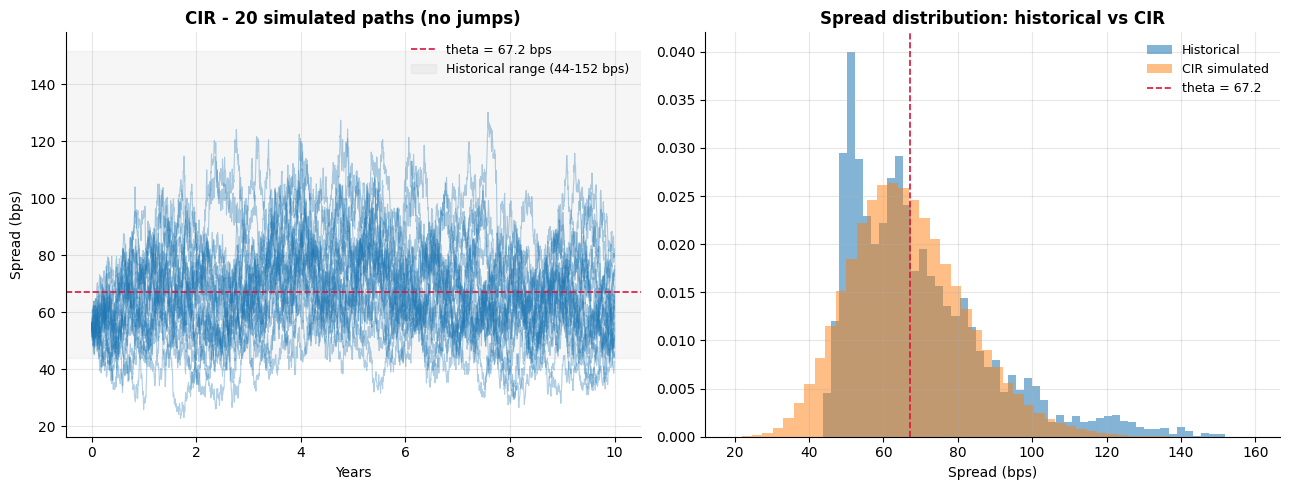

Simulated:  mean=66.79  std=15.62
Historical: mean=69.59  std=19.01


In [12]:
def simulate_cir_paths(cir, n_paths, T, dt=1/252, seed=42):
    n_steps  = int(T / dt)
    rng      = np.random.default_rng(seed)
    paths    = np.zeros((n_steps + 1, n_paths))
    paths[0] = cir.s0

    for t in range(n_steps):
        s    = np.maximum(paths[t], 1e-6)
        dW   = rng.standard_normal(n_paths) * np.sqrt(dt)
        ds   = cir.kappa * (cir.theta - s) * dt + cir.sigma * np.sqrt(s) * dW
        paths[t+1] = np.maximum(s + ds, 1e-6)

    return paths

# Generate paths for plotting (20) and distribution comparison (500)
paths_vis  = simulate_cir_paths(cir, n_paths=20,  T=cpdo.T, seed=42)
paths_dist = simulate_cir_paths(cir, n_paths=500, T=cpdo.T, seed=99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(time_axis, paths_vis, color='#1f77b4', alpha=0.35, linewidth=0.8)
ax.axhline(cir.theta, color='crimson', linestyle='--', linewidth=1.2,
           label=f'theta = {cir.theta:.1f} bps')
ax.axhspan(cdx['Spread'].min(), cdx['Spread'].max(), alpha=0.07, color='gray',
           label=f'Historical range ({cdx["Spread"].min():.0f}-{cdx["Spread"].max():.0f} bps)')
ax.set_xlabel('Years')
ax.set_ylabel('Spread (bps)')
ax.set_title('CIR - 20 simulated paths (no jumps)', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
sim_vals = paths_dist[1:].flatten()
ax.hist(cdx['Spread'], bins=50, alpha=0.55, color='#1f77b4', density=True, label='Historical')
ax.hist(sim_vals,      bins=50, alpha=0.50, color='#ff7f0e', density=True, label='CIR simulated')
ax.axvline(cir.theta, color='crimson', linestyle='--', linewidth=1.2,
           label=f'theta = {cir.theta:.1f}')
ax.set_xlabel('Spread (bps)')
ax.set_title('Spread distribution: historical vs CIR', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('outputs/04_cir_paths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Simulated:  mean={sim_vals.mean():.2f}  std={sim_vals.std():.2f}')
print(f'Historical: mean={spreads.mean():.2f}  std={spreads.std():.2f}')

---
## Section 4 — Jump Component

In [13]:
@dataclass
class JumpParams:
    jump_sizes:       np.ndarray  # empirical large moves, signed (bps)
    p_high:           float       # jump probability when spread is elevated
    p_low:            float       # jump probability when spread is normal
    spread_threshold: float       # boundary between high and normal regimes (bps)

def calibrate_jumps(spreads, tail_pct=85, regime_pct=80):
    s_t    = spreads[:-1]
    ds     = spreads[1:] - spreads[:-1]

    # Identify large moves in either direction (both widening and tightening)
    tail_threshold = np.percentile(np.abs(ds), tail_pct)
    is_large_move  = np.abs(ds) >= tail_threshold
    jump_sizes     = ds[is_large_move]

    # Probability of a jump differs by spread regime
    regime_threshold = np.percentile(s_t, regime_pct)
    in_high_regime   = s_t > regime_threshold

    p_high = min(is_large_move[in_high_regime].mean(),  0.10)
    p_low  = min(is_large_move[~in_high_regime].mean(), 0.05)

    return JumpParams(
        jump_sizes=jump_sizes,
        p_high=p_high,
        p_low=p_low,
        spread_threshold=regime_threshold
    )

jump = calibrate_jumps(spreads)

print(f'Large move threshold (|ds| pct-85):  {np.percentile(np.abs(spreads[1:]-spreads[:-1]), 85):.4f} bps')
print(f'Large move events:                   {len(jump.jump_sizes)} ({len(jump.jump_sizes)/len(spreads)*100:.1f}% of days)')
print(f'Jump mean:                            {jump.jump_sizes.mean():.4f} bps')
print(f'Jump std:                             {jump.jump_sizes.std():.4f} bps')
print(f'Jump range:                           {jump.jump_sizes.min():.2f} to {jump.jump_sizes.max():.2f} bps')
print()
print(f'Regime threshold (spread pct-80):     {jump.spread_threshold:.2f} bps')
print(f'p_high (spread above threshold):      {jump.p_high:.4f}')
print(f'p_low  (spread at or below):          {jump.p_low:.4f}')

Large move threshold (|ds| pct-85):  2.5151 bps
Large move events:                   548 (15.0% of days)
Jump mean:                            0.1781 bps
Jump std:                             5.4176 bps
Jump range:                           -31.39 to 27.78 bps

Regime threshold (spread pct-80):     82.71 bps
p_high (spread above threshold):      0.1000
p_low  (spread at or below):          0.0500


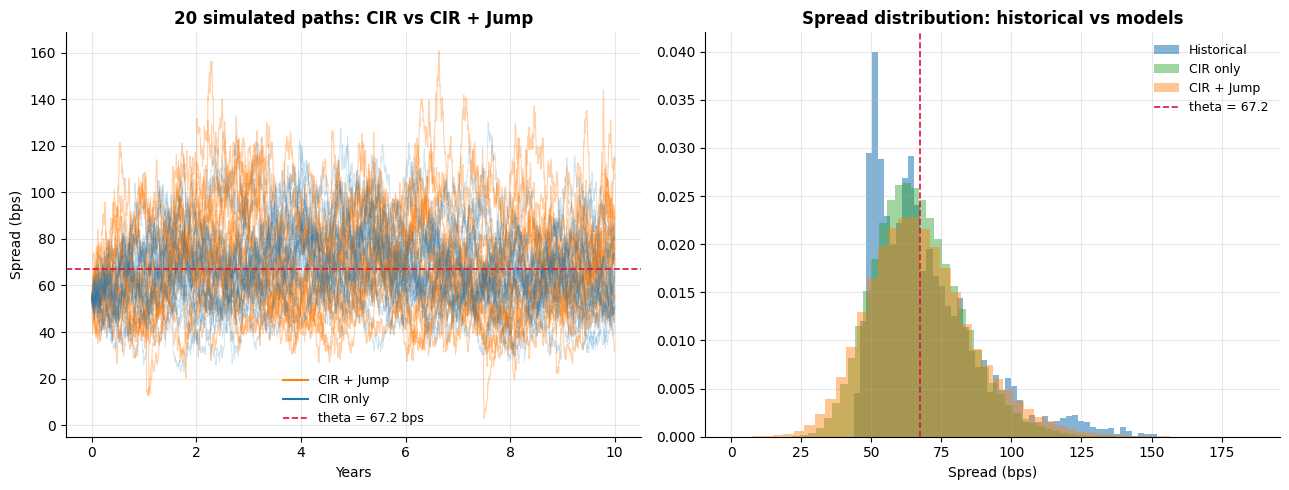

Historical: mean=69.59  std=19.01
CIR only:   mean=66.79  std=15.62
CIR + Jump: mean=67.68  std=18.66


In [14]:
def simulate_spread_paths(cir, jump, n_paths, T, dt=1/252, seed=42):
    n_steps  = int(T / dt)
    rng      = np.random.default_rng(seed)
    paths    = np.zeros((n_steps + 1, n_paths))
    paths[0] = cir.s0

    for step in range(n_steps):
        s   = np.maximum(paths[step], 1e-6)
        dW  = rng.standard_normal(n_paths) * np.sqrt(dt)
        ds  = cir.kappa * (cir.theta - s) * dt + cir.sigma * np.sqrt(s) * dW

        # Add a jump with state-dependent probability
        jump_prob  = np.where(s > jump.spread_threshold, jump.p_high, jump.p_low)
        jump_fires = rng.random(n_paths) < jump_prob
        ds        += jump_fires * rng.choice(jump.jump_sizes, size=n_paths)

        paths[step + 1] = np.clip(s + ds, 1e-6, 2000)

    return paths

# Generate paths for plotting and distribution comparison
cir_vis   = simulate_cir_paths(cir,         n_paths=20,  T=cpdo.T, seed=42)
jump_vis  = simulate_spread_paths(cir, jump, n_paths=20,  T=cpdo.T, seed=42)
cir_dist  = simulate_cir_paths(cir,         n_paths=500, T=cpdo.T, seed=99)
jump_dist = simulate_spread_paths(cir, jump, n_paths=500, T=cpdo.T, seed=99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 20 paths — no label on multi-column plot, use manual legend handles
ax = axes[0]
ax.plot(time_axis, jump_vis, color='#ff7f0e', alpha=0.35, linewidth=0.8)
ax.plot(time_axis, cir_vis,  color='#1f77b4', alpha=0.20, linewidth=0.6)
ax.axhline(cir.theta, color='crimson', linestyle='--', linewidth=1.2)
ax.set_xlabel('Years')
ax.set_ylabel('Spread (bps)')
ax.set_title('20 simulated paths: CIR vs CIR + Jump', fontweight='bold')
ax.legend(handles=[
    Line2D([0], [0], color='#ff7f0e', lw=1.5, label='CIR + Jump'),
    Line2D([0], [0], color='#1f77b4', lw=1.5, label='CIR only'),
    Line2D([0], [0], color='crimson',  lw=1.2, linestyle='--', label=f'theta = {cir.theta:.1f} bps'),
], frameon=False, fontsize=9)

# Right: three-way distribution comparison
ax = axes[1]
ax.hist(spreads,                bins=50, alpha=0.55, color='#1f77b4', density=True, label='Historical')
ax.hist(cir_dist[1:].flatten(), bins=50, alpha=0.45, color='#2ca02c', density=True, label='CIR only')
ax.hist(jump_dist[1:].flatten(),bins=50, alpha=0.45, color='#ff7f0e', density=True, label='CIR + Jump')
ax.axvline(cir.theta, color='crimson', linestyle='--', linewidth=1.2,
           label=f'theta = {cir.theta:.1f}')
ax.set_xlabel('Spread (bps)')
ax.set_title('Spread distribution: historical vs models', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('outputs/05_cir_jump_paths.png', dpi=150, bbox_inches='tight')
plt.show()

v_cir  = cir_dist[1:].flatten()
v_jump = jump_dist[1:].flatten()
print(f'Historical: mean={spreads.mean():.2f}  std={spreads.std():.2f}')
print(f'CIR only:   mean={v_cir.mean():.2f}  std={v_cir.std():.2f}')
print(f'CIR + Jump: mean={v_jump.mean():.2f}  std={v_jump.std():.2f}')

---
## Section 5 — Default Loss Model

In [15]:
# Default intensity derived from the no-arbitrage condition: spread = lambda * LGD * risky_duration
def compute_default_loss(exposure, spread, rng, n_paths, cpdo):
    lgd_local         = 1.0 - cpdo.recovery_rate
    lambda_per_name   = spread / (10_000 * lgd_local * cpdo.risky_duration)
    expected_defaults = cpdo.n_names * lambda_per_name * cpdo.dt
    n_defaults        = rng.poisson(expected_defaults, size=n_paths)
    return n_defaults * (1.0 / cpdo.n_names) * exposure * lgd_local

# Sanity check at representative values: L~8x, NAV=100, spread=70bps
lev_check    = compute_leverage(100.0, 70.0, 252, cpdo)
exp_check    = lev_check * 100.0
spread_check = 70.0

lambda_rn        = spread_check / (10_000 * lgd * cpdo.risky_duration)
per_name_loss    = (1 / cpdo.n_names) * exp_check * lgd
ann_default_loss = cpdo.n_names * lambda_rn * per_name_loss
ann_carry        = exp_check * spread_check / 10_000

print(f'lambda_rn (per name per year):   {lambda_rn:.5f}  ({lambda_rn*100:.3f}%)')
print(f'per-name default loss:           {per_name_loss:.4f}  ({per_name_loss/exp_check*100:.3f}% of exposure)')
print(f'expected annual default loss:    {ann_default_loss:.4f}')
print(f'annual carry income:             {ann_carry:.4f}')
print(f'default loss / carry:            {ann_default_loss/ann_carry:.1%}')
print(f'MTM per 1bp widening:            {exp_check * cpdo.risky_duration * 1e-4:.4f}')

lambda_rn (per name per year):   0.00259  (0.259%)
per-name default loss:           3.8095  (0.480% of exposure)
expected annual default loss:    1.2346
annual carry income:             5.5556
default loss / carry:            22.2%
MTM per 1bp widening:            0.3571


---
## Section 6 — Monte Carlo Simulation (Base Case)

In [56]:
# SOFR fixed at the historical mean over the CDX sample period (Sep 2011 - Apr 2026)
# The mean (2.119%) is more representative than the last observed value for a 10-year simulation.
# SOFR and interest income largely cancel in the net carry; only the 150 bps investor spread matters.
sofr_rate = sofr[sofr['Date'] >= cdx['Date'].min()]['Rate'].mean()
print(f'SOFR rate used: {sofr_rate*100:.3f}%  (mean over CDX period)')

def run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=123,
                        s0_override=None, shock_bps=0.0, shock_year=None,
                        record=False):
    dt      = cpdo.dt
    n_steps = int(cpdo.T / dt)
    rng     = np.random.default_rng(seed)

    # Build spread paths, optionally starting from a different level
    cir_eff = CIRParams(
        kappa=cir.kappa, theta=cir.theta, sigma=cir.sigma,
        s0=s0_override if s0_override is not None else cir.s0
    )
    spread_paths = simulate_spread_paths(cir_eff, jump, n_paths, cpdo.T, dt=dt, seed=seed + 1)

    # Apply a permanent spread shock from a given year (Scenario B)
    if shock_bps > 0 and shock_year is not None:
        shock_step = int(shock_year / dt)
        spread_paths[shock_step:] = np.clip(spread_paths[shock_step:] + shock_bps, 1e-6, 2000)

    nav        = np.full(n_paths, cpdo.initial_nav, dtype=float)
    active     = np.ones(n_paths, dtype=bool)
    defaulted  = np.zeros(n_paths, dtype=bool)
    cashed_out = np.zeros(n_paths, dtype=bool)
    event_step = np.full(n_paths, n_steps, dtype=int)
    coupon_acc = 0.0

    if record:
        nav_history = np.zeros((n_steps + 1, n_paths))
        nav_history[0] = nav

    for step in range(n_steps):
        if not active.any():
            break

        spread = spread_paths[step]
        ds     = spread_paths[step + 1] - spread_paths[step]
        lev    = compute_leverage(nav, spread, step, cpdo)
        exp    = lev * nav

        carry    = exp * (spread / 10_000) * dt
        interest = sofr_rate * nav * dt
        mtm      = -exp * cpdo.risky_duration * 1e-4 * ds
        def_loss = compute_default_loss(exp, spread, rng, n_paths, cpdo)
        fee      = cpdo.management_fee * nav * dt
        roll     = cpdo.roll_cost_bps * 1e-4 * exp if (step > 0 and step % cpdo.roll_every == 0) else 0.0

        # Accrue and pay coupon quarterly (every 63 steps)
        coupon_acc += (sofr_rate + cpdo.investor_spread) * cpdo.initial_nav * dt
        coupon_pay  = coupon_acc if (step + 1) % 63 == 0 else 0.0
        if (step + 1) % 63 == 0:
            coupon_acc = 0.0

        delta_nav = carry + interest + mtm - def_loss - fee - roll - coupon_pay
        nav = np.where(active, nav + delta_nav, nav)

        # Check triggers
        hit_floor  = active & (nav <= cpdo.floor_nav)
        hit_target = active & (nav >= cpdo.target_nav)
        hit        = hit_floor | hit_target

        event_step  = np.where(hit, step, event_step)
        defaulted  |= hit_floor
        cashed_out |= hit_target
        nav         = np.where(hit_floor,  cpdo.floor_nav,  nav)
        nav         = np.where(hit_target, cpdo.target_nav, nav)
        active     &= ~hit

        if record:
            nav_history[step + 1] = nav

    result = dict(
        final_nav  = nav,
        defaulted  = defaulted,
        cashed_out = cashed_out,
        event_year = event_step * dt,
    )
    if record:
        result['nav_history'] = nav_history

    return result

SOFR rate used: 2.119%  (mean over CDX period)


In [57]:
t0  = time.time()
res = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=123)
print(f'Runtime: {time.time()-t0:.1f}s')

n_paths    = len(res['final_nav'])
pd_rate    = res['defaulted'].mean()
co_rate    = res['cashed_out'].mean()
alive_rate = 1 - pd_rate - co_rate

print(f'n = {n_paths:,} paths')
print(f'  Defaulted:  {pd_rate*100:.2f}%  (NAV <= {cpdo.floor_nav})')
print(f'  Cashed out: {co_rate*100:.2f}%  (NAV >= {cpdo.target_nav:.0f})')
print(f'  Alive:      {alive_rate*100:.2f}%')
print()
print(f'Final NAV:  mean={res["final_nav"].mean():.2f}  median={np.median(res["final_nav"]):.2f}  min={res["final_nav"].min():.2f}')

Runtime: 3.0s
n = 10,000 paths
  Defaulted:  0.00%  (NAV <= 10.0)
  Cashed out: 34.99%  (NAV >= 150)
  Alive:      65.01%

Final NAV:  mean=119.25  median=116.90  min=41.84


---
## Section 7 — Results & Analysis (Base Case)

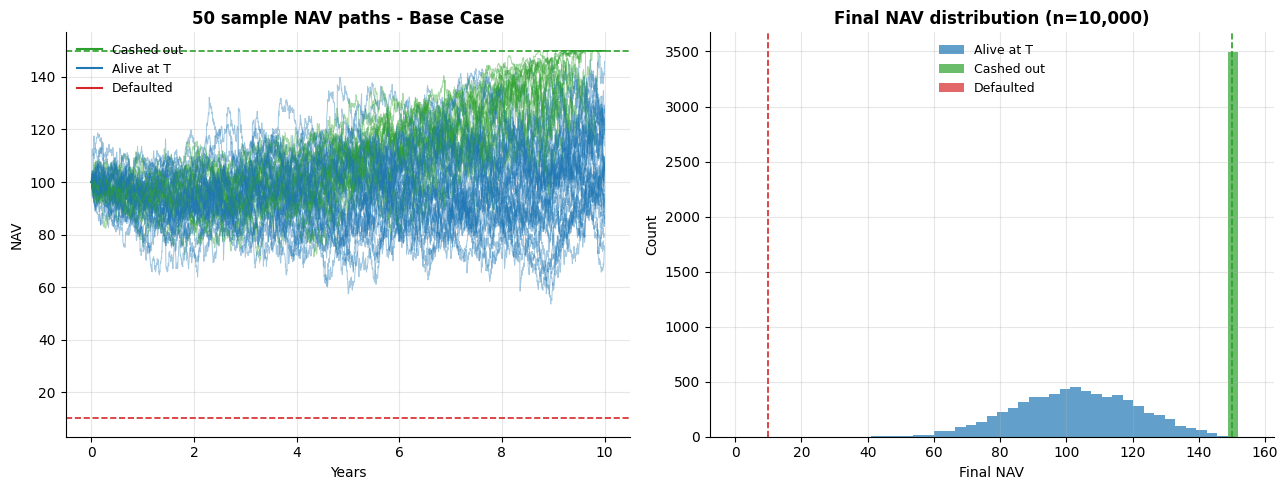

PD:         0.00%
Cash-out:   34.99%
Alive:      65.01%
Mean NAV:   119.25  |  Median: 116.90


In [58]:
# Run 50-path simulation with full NAV history recorded for plotting
res50    = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=50, seed=42, record=True)
nav_hist = res50['nav_history']
def50    = res50['defaulted']
co50     = res50['cashed_out']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i in range(nav_hist.shape[1]):
    color = '#2ca02c' if co50[i] else ('#d62728' if def50[i] else '#1f77b4')
    ax.plot(time_axis, nav_hist[:, i], color=color, alpha=0.4, linewidth=0.7)

ax.axhline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.2, label=f'Target NAV ({cpdo.target_nav})')
ax.axhline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.2, label=f'Floor NAV ({cpdo.floor_nav})')
ax.set_xlabel('Years')
ax.set_ylabel('NAV')
ax.set_title('50 sample NAV paths - Base Case', fontweight='bold')
legend_handles = [
    Line2D([0], [0], color='#2ca02c', lw=1.5, label='Cashed out'),
    Line2D([0], [0], color='#1f77b4', lw=1.5, label='Alive at T'),
    Line2D([0], [0], color='#d62728', lw=1.5, label='Defaulted'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=9)

ax = axes[1]
bins = np.linspace(0, 155, 50)
ax.hist(res['final_nav'][~res['defaulted'] & ~res['cashed_out']], bins=bins, color='#1f77b4', alpha=0.7, label='Alive at T')
ax.hist(res['final_nav'][res['cashed_out']],  bins=bins, color='#2ca02c', alpha=0.7, label='Cashed out')
ax.hist(res['final_nav'][res['defaulted']],   bins=bins, color='#d62728', alpha=0.7, label='Defaulted')
ax.axvline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.2)
ax.axvline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.2)
ax.set_xlabel('Final NAV')
ax.set_ylabel('Count')
ax.set_title('Final NAV distribution (n=10,000)', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('outputs/06_nav_base_case.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PD:         {res["defaulted"].mean()*100:.2f}%')
print(f'Cash-out:   {res["cashed_out"].mean()*100:.2f}%')
print(f'Alive:      {(~res["defaulted"] & ~res["cashed_out"]).mean()*100:.2f}%')
print(f'Mean NAV:   {res["final_nav"].mean():.2f}  |  Median: {np.median(res["final_nav"]):.2f}')

---
## Section 9 — Stress Tests

Scenario A (3.1s):  PD=0.00%  Cash-out=96.25%  Mean NAV=148.71
Scenario B (3.4s):  PD=39.33%  Cash-out=3.28%  Mean NAV=45.15


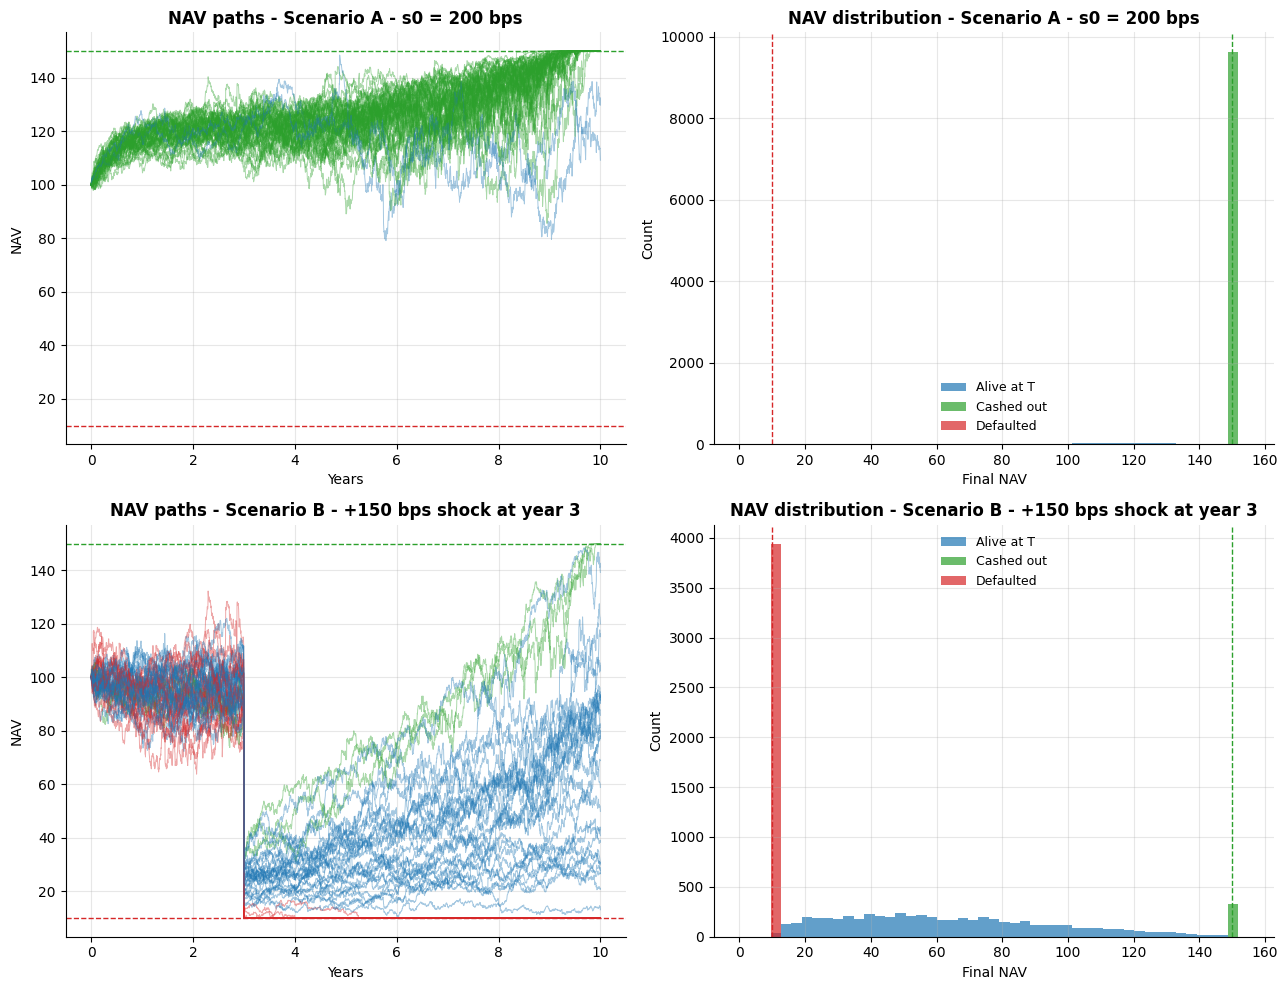

In [59]:
# Scenario A: CPDO issued when spreads are at GFC-era level (s0 = 200 bps)
t0    = time.time()
res_A = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=456, s0_override=200.0)
print(f'Scenario A ({time.time()-t0:.1f}s):  PD={res_A["defaulted"].mean()*100:.2f}%  '
      f'Cash-out={res_A["cashed_out"].mean()*100:.2f}%  '
      f'Mean NAV={res_A["final_nav"].mean():.2f}')

# Scenario B: spread jumps permanently by +150 bps at year 3 (GFC-style mid-life shock)
t0    = time.time()
res_B = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=456,
                             shock_bps=150.0, shock_year=3.0)
print(f'Scenario B ({time.time()-t0:.1f}s):  PD={res_B["defaulted"].mean()*100:.2f}%  '
      f'Cash-out={res_B["cashed_out"].mean()*100:.2f}%  '
      f'Mean NAV={res_B["final_nav"].mean():.2f}')

# Record 50-path histories for plotting
res50_A = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=50, seed=42,
                               s0_override=200.0, record=True)
res50_B = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=50, seed=42,
                               shock_bps=150.0, shock_year=3.0, record=True)

stress_scenarios = [
    (res50_A, res_A, 'Scenario A - s0 = 200 bps'),
    (res50_B, res_B, 'Scenario B - +150 bps shock at year 3'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (r50, r_full, title) in enumerate(stress_scenarios):
    nav_traj = r50['nav_history']
    def_traj = r50['defaulted']
    co_traj  = r50['cashed_out']

    ax = axes[row, 0]
    for i in range(nav_traj.shape[1]):
        color = '#2ca02c' if co_traj[i] else ('#d62728' if def_traj[i] else '#1f77b4')
        ax.plot(time_axis, nav_traj[:, i], color=color, alpha=0.4, linewidth=0.7)
    ax.axhline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.0)
    ax.axhline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.0)
    ax.set_xlabel('Years')
    ax.set_ylabel('NAV')
    ax.set_title(f'NAV paths - {title}', fontweight='bold')

    ax   = axes[row, 1]
    bins = np.linspace(0, 155, 50)
    ax.hist(r_full['final_nav'][~r_full['defaulted'] & ~r_full['cashed_out']],
            bins=bins, color='#1f77b4', alpha=0.7, label='Alive at T')
    ax.hist(r_full['final_nav'][r_full['cashed_out']],
            bins=bins, color='#2ca02c', alpha=0.7, label='Cashed out')
    ax.hist(r_full['final_nav'][r_full['defaulted']],
            bins=bins, color='#d62728', alpha=0.7, label='Defaulted')
    ax.axvline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.0)
    ax.axvline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.0)
    ax.set_xlabel('Final NAV')
    ax.set_ylabel('Count')
    ax.set_title(f'NAV distribution - {title}', fontweight='bold')
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('outputs/07_stress_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Summary table across all three scenarios
summary = {
    'Base (s0 = 54 bps)':            res,
    'Scenario A (s0 = 200 bps)':     res_A,
    'Scenario B (+150 bps at yr 3)': res_B,
}

print(f'{"Scenario":<35} {"PD":>8} {"Cash-out":>10} {"Alive":>8} {"Mean NAV":>10} {"Median NAV":>11}')
print('-' * 85)
for label, r in summary.items():
    pd_   = r['defaulted'].mean()
    co_   = r['cashed_out'].mean()
    alive = 1 - pd_ - co_
    mean  = r['final_nav'].mean()
    med   = np.median(r['final_nav'])
    print(f'{label:<35} {pd_*100:>7.2f}% {co_*100:>9.2f}% {alive*100:>7.2f}% {mean:>10.2f} {med:>11.2f}')

Scenario                                  PD   Cash-out    Alive   Mean NAV  Median NAV
-------------------------------------------------------------------------------------
Base (s0 = 54 bps)                     0.00%     34.99%   65.01%     119.25      116.90
Scenario A (s0 = 200 bps)              0.00%     96.25%    3.75%     148.71      150.00
Scenario B (+150 bps at yr 3)         39.33%      3.28%   57.39%      45.15       31.87


---
## Section 8 — Rating Grade Assignment

In [62]:
# S&P approximate 1-year historical average PDs by rating (from S&P default studies)
rating_table = pd.DataFrame([
    ('AAA',    0.00, 'Aaa'),
    ('AA',     0.02, 'Aa'),
    ('A',      0.07, 'A'),
    ('BBB',    0.24, 'Baa'),
    ('BB',     0.97, 'Ba'),
    ('B',      4.44, 'B'),
    ('CCC/C', 26.06, 'Caa/C'),
], columns=["S&P", "Annual PD (%)", "Moody's"])

print(rating_table.to_string(index=False))
print()

def to_annual_pd(pd_10yr):
    return (1 - (1 - pd_10yr) ** (1 / 10)) * 100

def assign_rating(annual_pd_pct):
    if   annual_pd_pct < 0.01: return 'AAA'
    elif annual_pd_pct < 0.05: return 'AA'
    elif annual_pd_pct < 0.15: return 'A'
    elif annual_pd_pct < 0.60: return 'BBB'
    elif annual_pd_pct < 2.70: return 'BB'
    elif annual_pd_pct < 15.0: return 'B'
    else:                      return 'CCC/C'

scenarios = [
    ('Base case (s0 = 54 bps)',         res),
    ('Scenario A (s0 = 200 bps)',        res_A),
    ('Scenario B (+150 bps at yr 3)',    res_B),
]

print(f'{"Scenario":<32}  {"PD 10yr":>8}  {"Annual PD":>10}  {"Implied":>8}  {"Actual (2005)":>13}')
print('-' * 78)
for label, r in scenarios:
    pd_10  = r['defaulted'].mean()
    apd    = to_annual_pd(pd_10)
    rating = assign_rating(apd)
    print(f'{label:<32}  {pd_10*100:>7.2f}%  {apd:>9.4f}%  {rating:>8}  {"AAA":>13}')

  S&P  Annual PD (%) Moody's
  AAA           0.00     Aaa
   AA           0.02      Aa
    A           0.07       A
  BBB           0.24     Baa
   BB           0.97      Ba
    B           4.44       B
CCC/C          26.06   Caa/C

Scenario                           PD 10yr   Annual PD   Implied  Actual (2005)
------------------------------------------------------------------------------
Base case (s0 = 54 bps)              0.00%     0.0000%       AAA            AAA
Scenario A (s0 = 200 bps)            0.00%     0.0000%       AAA            AAA
Scenario B (+150 bps at yr 3)       39.33%     4.8744%         B            AAA


---
## Section 10 — Sensitivity Analysis

Runtime: 20.0s


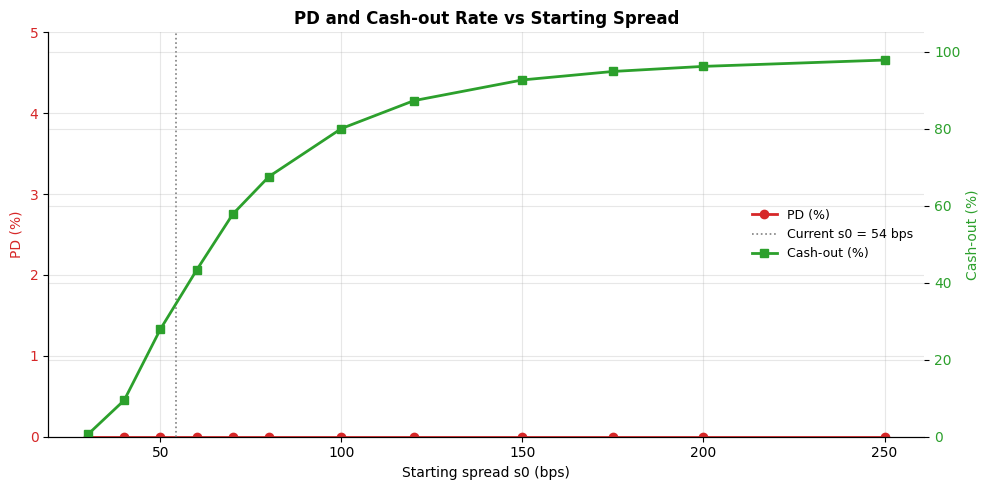

  s0 (bps)        PD    Cash-out
--------------------------------
        30     0.00%       0.62%
        40     0.00%       9.46%
        50     0.00%      27.92%
        60     0.00%      43.26%
        70     0.00%      57.80%
        80     0.00%      67.56%
       100     0.00%      80.02%
       120     0.00%      87.26%
       150     0.00%      92.64%
       175     0.00%      94.84%
       200     0.00%      96.16%
       250     0.00%      97.80%


In [63]:
# Starting spread sweep — PD and cash-out rate vs s0 (5,000 paths per point)
s0_values = [30, 40, 50, 60, 70, 80, 100, 120, 150, 175, 200, 250]
pd_sweep  = []
co_sweep  = []

t0 = time.time()
for s0 in s0_values:
    r = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=5_000, seed=42, s0_override=float(s0))
    pd_sweep.append(r['defaulted'].mean() * 100)
    co_sweep.append(r['cashed_out'].mean() * 100)
print(f'Runtime: {time.time()-t0:.1f}s')

fig, ax1 = plt.subplots(figsize=(10, 5))

color_pd = '#d62728'
color_co = '#2ca02c'

ax1.plot(s0_values, pd_sweep, color=color_pd, marker='o', linewidth=2, markersize=6, label='PD (%)')
ax1.set_xlabel('Starting spread s0 (bps)')
ax1.set_ylabel('PD (%)', color=color_pd)
ax1.tick_params(axis='y', labelcolor=color_pd)
ax1.set_ylim(0, max(max(pd_sweep) * 1.3, 5))
ax1.axvline(cir.s0, color='gray', linestyle=':', linewidth=1.2, label=f'Current s0 = {cir.s0:.0f} bps')

ax2 = ax1.twinx()
ax2.plot(s0_values, co_sweep, color=color_co, marker='s', linewidth=2, markersize=6, label='Cash-out (%)')
ax2.set_ylabel('Cash-out (%)', color=color_co)
ax2.tick_params(axis='y', labelcolor=color_co)
ax2.set_ylim(0, 105)

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9, loc='center right')

ax1.set_title('PD and Cash-out Rate vs Starting Spread', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/08_spread_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"s0 (bps)":>10}  {"PD":>8}  {"Cash-out":>10}')
print('-' * 32)
for s0, pd, co in zip(s0_values, pd_sweep, co_sweep):
    print(f'{s0:>10}  {pd:>7.2f}%  {co:>9.2f}%')

Runtime: 44.1s


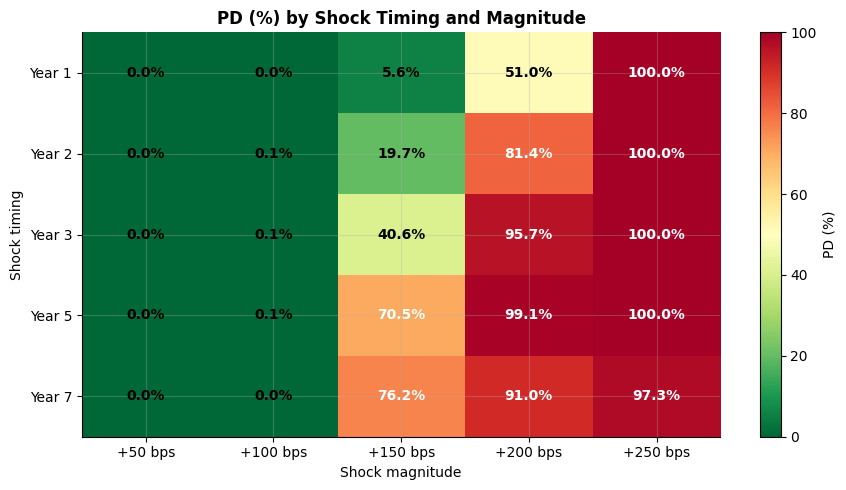

In [64]:
# Shock magnitude vs shock timing — PD heatmap (5,000 paths per cell)
shock_bps_list  = [50, 100, 150, 200, 250]
shock_year_list = [1, 2, 3, 5, 7]

pd_grid = np.zeros((len(shock_year_list), len(shock_bps_list)))

t0 = time.time()
for i, year in enumerate(shock_year_list):
    for j, bps in enumerate(shock_bps_list):
        r = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=5_000, seed=42,
                                shock_bps=float(bps), shock_year=float(year))
        pd_grid[i, j] = r['defaulted'].mean() * 100
print(f'Runtime: {time.time()-t0:.1f}s')

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pd_grid, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='PD (%)')

for i in range(len(shock_year_list)):
    for j in range(len(shock_bps_list)):
        text_color = 'white' if pd_grid[i, j] > 70 else 'black'
        ax.text(j, i, f'{pd_grid[i, j]:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

ax.set_xticks(range(len(shock_bps_list)))
ax.set_xticklabels([f'+{b} bps' for b in shock_bps_list])
ax.set_yticks(range(len(shock_year_list)))
ax.set_yticklabels([f'Year {y}' for y in shock_year_list])
ax.set_xlabel('Shock magnitude')
ax.set_ylabel('Shock timing')
ax.set_title('PD (%) by Shock Timing and Magnitude', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/09_shock_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Runtime: 20.5s


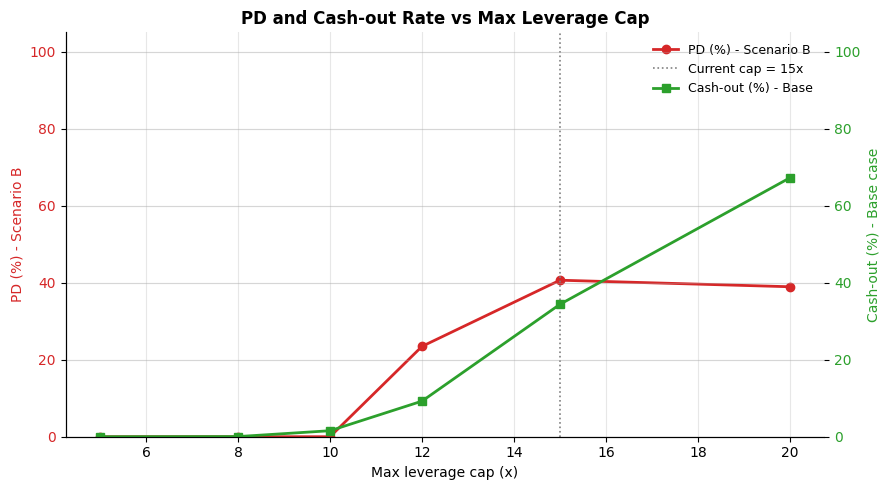

 Max lev   PD (stress)   Cash-out (base)
----------------------------------------
      5x         0.00%             0.00%
      8x         0.00%             0.04%
     10x         0.00%             1.56%
     12x        23.46%             9.24%
     15x        40.64%            34.38%
     20x        38.94%            67.22%


In [65]:
# Max leverage cap sweep — base case cash-out and Scenario B PD vs cap (5,000 paths)
max_leverage_values = [5, 8, 10, 12, 15, 20]

pd_stress_lev = []
co_base_lev   = []

t0 = time.time()
for ml in max_leverage_values:
    cpdo_mod = CPDOParams(max_leverage=float(ml))

    r_base = run_cpdo_simulation(cir, jump, cpdo_mod, sofr_rate, n_paths=5_000, seed=42)
    co_base_lev.append(r_base['cashed_out'].mean() * 100)

    r_stress = run_cpdo_simulation(cir, jump, cpdo_mod, sofr_rate, n_paths=5_000, seed=42,
                                   shock_bps=150.0, shock_year=3.0)
    pd_stress_lev.append(r_stress['defaulted'].mean() * 100)
print(f'Runtime: {time.time()-t0:.1f}s')

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(max_leverage_values, pd_stress_lev, color='#d62728', marker='o', linewidth=2,
         markersize=6, label='PD (%) - Scenario B')
ax1.set_xlabel('Max leverage cap (x)')
ax1.set_ylabel('PD (%) - Scenario B', color='#d62728')
ax1.tick_params(axis='y', labelcolor='#d62728')
ax1.set_ylim(0, 105)
ax1.axvline(cpdo.max_leverage, color='gray', linestyle=':', linewidth=1.2,
            label=f'Current cap = {cpdo.max_leverage:.0f}x')

ax2 = ax1.twinx()
ax2.plot(max_leverage_values, co_base_lev, color='#2ca02c', marker='s', linewidth=2,
         markersize=6, label='Cash-out (%) - Base')
ax2.set_ylabel('Cash-out (%) - Base case', color='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9)

ax1.set_title('PD and Cash-out Rate vs Max Leverage Cap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/10_leverage_cap_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Max lev":>8}  {"PD (stress)":>12}  {"Cash-out (base)":>16}')
print('-' * 40)
for ml, pd_s, co_b in zip(max_leverage_values, pd_stress_lev, co_base_lev):
    print(f'{ml:>7}x  {pd_s:>11.2f}%  {co_b:>15.2f}%')

Runtime: 27.3s


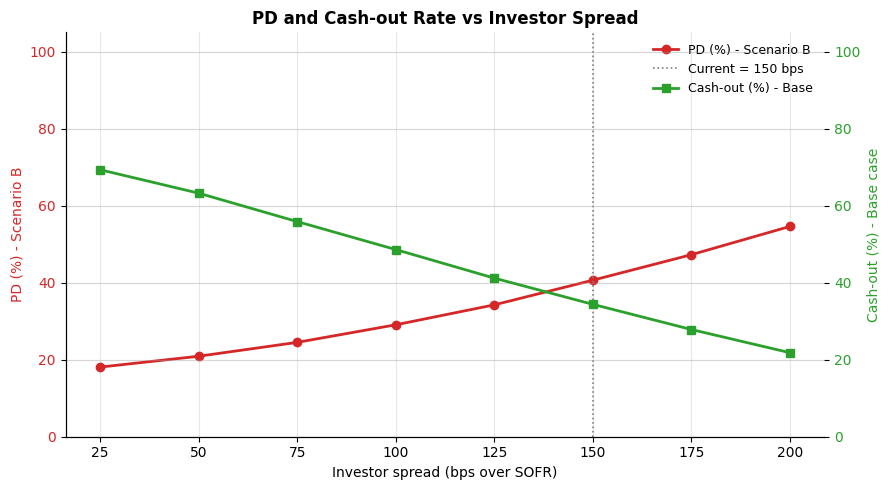

Spread (bps)   PD (stress)   Cash-out (base)
--------------------------------------------
          25        18.08%            69.32%
          50        20.90%            63.24%
          75        24.50%            55.86%
         100        29.06%            48.60%
         125        34.24%            41.18%
         150        40.64%            34.38%
         175        47.26%            27.84%
         200        54.60%            21.82%


In [66]:
# Investor spread sweep — base case cash-out and Scenario B PD vs coupon spread (5,000 paths)
investor_bps = [25, 50, 75, 100, 125, 150, 175, 200]

pd_stress_inv = []
co_base_inv   = []

t0 = time.time()
for bps in investor_bps:
    cpdo_mod = CPDOParams(investor_spread=bps / 10_000)

    r_base = run_cpdo_simulation(cir, jump, cpdo_mod, sofr_rate, n_paths=5_000, seed=42)
    co_base_inv.append(r_base['cashed_out'].mean() * 100)

    r_stress = run_cpdo_simulation(cir, jump, cpdo_mod, sofr_rate, n_paths=5_000, seed=42,
                                   shock_bps=150.0, shock_year=3.0)
    pd_stress_inv.append(r_stress['defaulted'].mean() * 100)
print(f'Runtime: {time.time()-t0:.1f}s')

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(investor_bps, pd_stress_inv, color='#d62728', marker='o', linewidth=2,
         markersize=6, label='PD (%) - Scenario B')
ax1.set_xlabel('Investor spread (bps over SOFR)')
ax1.set_ylabel('PD (%) - Scenario B', color='#d62728')
ax1.tick_params(axis='y', labelcolor='#d62728')
ax1.set_ylim(0, 105)
ax1.axvline(cpdo.investor_spread * 10_000, color='gray', linestyle=':', linewidth=1.2,
            label=f'Current = {cpdo.investor_spread*10_000:.0f} bps')

ax2 = ax1.twinx()
ax2.plot(investor_bps, co_base_inv, color='#2ca02c', marker='s', linewidth=2,
         markersize=6, label='Cash-out (%) - Base')
ax2.set_ylabel('Cash-out (%) - Base case', color='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9)

ax1.set_title('PD and Cash-out Rate vs Investor Spread', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/11_investor_spread_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Spread (bps)":>12}  {"PD (stress)":>12}  {"Cash-out (base)":>16}')
print('-' * 44)
for bps, pd_s, co_b in zip(investor_bps, pd_stress_inv, co_base_inv):
    print(f'{bps:>12}  {pd_s:>11.2f}%  {co_b:>15.2f}%')